In [3]:
!pip install matplotlib


     |████████████████████████████████| 8.3 MB 15.3 MB/s            
     |████████████████████████████████| 122 kB 111.5 MB/s            
     |████████████████████████████████| 321 kB 104.4 MB/s            
     |████████████████████████████████| 6.6 MB 72.6 MB/s            
     |████████████████████████████████| 4.8 MB 109.0 MB/s            
     |████████████████████████████████| 1.6 MB 60.6 MB/s            


Percentiles for number of comments per post (computed from comments file):
  0th percentile = 0
 10th percentile = 0
 25th percentile = 1
 50th percentile = 2
 75th percentile = 5
 90th percentile = 9
100th percentile = 176

Q1 (25%) = 1
Median (50%) = 2
Q3 (75%) = 5
IQR = 4
Min = 0, Max = 176
Number of posts = 1471


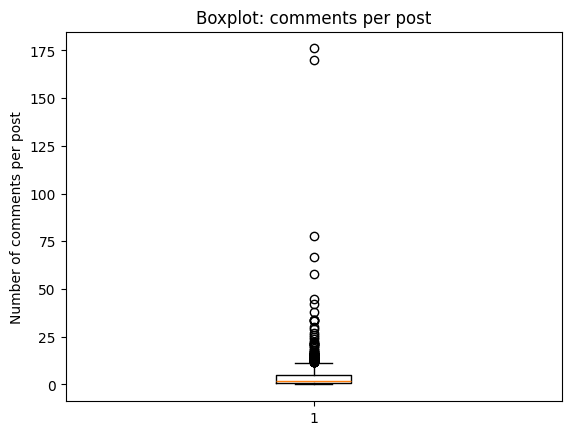

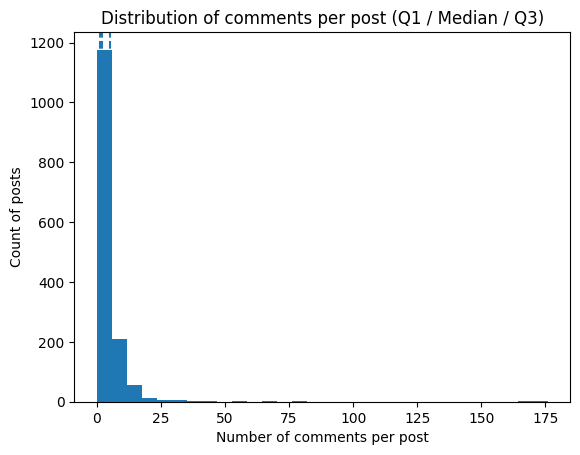


Sanity check:
Average absolute difference between num_comments_listed and computed = 1.5465669612508497
Posts where they differ = 569


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

POSTS_PATH = "../data/Ambivalent_Data_Final.csv"
COMMENTS_PATH = "../data/Ambivalent_Comments_Final.csv"

posts = pd.read_csv(POSTS_PATH)
comments = pd.read_csv(COMMENTS_PATH)

# 1) True comment count per post from the comments file
comment_counts = (
    comments.groupby("post_id")
    .size()
    .rename("num_comments_from_comments_file")
    .reset_index()
)

# 2) Attach to posts (so every post gets a count, missing -> 0)
df = posts[["post_id", "num_comments_listed"]].merge(comment_counts, on="post_id", how="left")
df["num_comments_from_comments_file"] = df["num_comments_from_comments_file"].fillna(0).astype(int)

x = df["num_comments_from_comments_file"].to_numpy()

# 3) Percentiles / quartiles
ps = [0, 10, 25, 50, 75, 90, 100]
vals = np.percentile(x, ps)

print("Percentiles for number of comments per post (computed from comments file):")
for p, v in zip(ps, vals):
    print(f"{p:>3}th percentile = {v:.0f}")

q1, med, q3 = np.percentile(x, [25, 50, 75])
print(f"\nQ1 (25%) = {q1:.0f}")
print(f"Median (50%) = {med:.0f}")
print(f"Q3 (75%) = {q3:.0f}")
print(f"IQR = {q3 - q1:.0f}")
print(f"Min = {x.min()}, Max = {x.max()}")
print(f"Number of posts = {len(x)}")

# 4) Boxplot (matches what your advisor showed)
plt.figure()
plt.boxplot(x, vert=True, showfliers=True)
plt.ylabel("Number of comments per post")
plt.title("Boxplot: comments per post")
plt.show()

# 5) Optional: histogram to "see" the distribution shape
plt.figure()
plt.hist(x, bins=30)
plt.axvline(q1, linestyle="--")
plt.axvline(med, linestyle="--")
plt.axvline(q3, linestyle="--")
plt.xlabel("Number of comments per post")
plt.ylabel("Count of posts")
plt.title("Distribution of comments per post (Q1 / Median / Q3)")
plt.show()

# 6) Optional sanity check: compare listed vs computed counts
# (If num_comments_listed is from Reddit metadata, it may not exactly match your extracted comments.)
diff = (df["num_comments_listed"].fillna(0).astype(int) - df["num_comments_from_comments_file"]).abs()
print("\nSanity check:")
print("Average absolute difference between num_comments_listed and computed =", diff.mean())
print("Posts where they differ =", (diff > 0).sum())


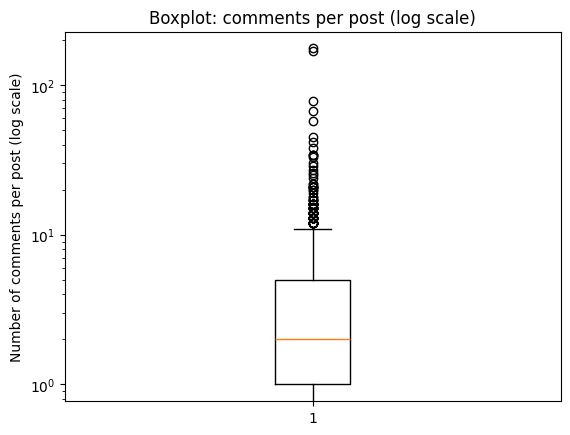

In [5]:
plt.figure()
plt.boxplot(x, vert=True, showfliers=True)
plt.yscale("log")
plt.ylabel("Number of comments per post (log scale)")
plt.title("Boxplot: comments per post (log scale)")
plt.show()
